# Entrenamiento del Modelo
### Detección de Neumonía Bacteriana y Viral — Grupo 8



## 0. Configuración del entorno e instalación de librerías

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.10.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Cargar los splits del codigo anterior



In [2]:
OUTPUT_DIR = './outputs'
DATA_DIR = os.path.join(OUTPUT_DIR, 'data')

assert os.path.isdir(DATA_DIR), (
    f"No se encontró '{DATA_DIR}'. Corre primero 01_Preprocesamiento.ipynb, "
    f"o ajusta OUTPUT_DIR para que apunte a la carpeta correcta."
)

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_df.csv'))
val_df = pd.read_csv(os.path.join(DATA_DIR, 'val_df.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_df.csv'))

with open(os.path.join(DATA_DIR, 'classes.txt')) as f:
    CLASSES = [line.strip() for line in f if line.strip()]

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("Clases:", CLASSES)
train_df.head()


Train: 4684  Val: 586  Test: 586
Clases: ['normal', 'bacteria', 'virus']


,filepath,label
0,D:\Escritorio\Espol\IA\chest_xray\train\NORMAL...,normal
1,D:\Escritorio\Espol\IA\chest_xray\train\PNEUMO...,bacteria
2,D:\Escritorio\Espol\IA\chest_xray\train\PNEUMO...,bacteria
3,D:\Escritorio\Espol\IA\chest_xray\train\NORMAL...,normal
4,D:\Escritorio\Espol\IA\chest_xray\train\NORMAL...,normal


## 2. Redimensionamiento, normalización y pipeline de datos


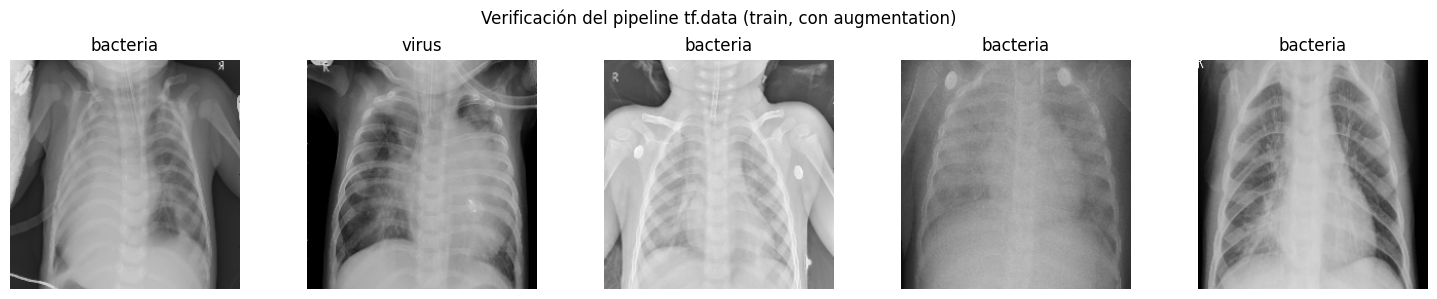

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}  # {'normal':0, 'bacteria':1, 'virus':2}

def load_and_preprocess(filepath, label_idx, augment=False):
    """Un solo lugar, explícito y legible, con TODO el preprocesamiento de una imagen."""
    raw = tf.io.read_file(filepath)
    img = tf.io.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = img / 255.0

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.08)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
        crop_frac = tf.random.uniform([], 0.9, 1.0)
        crop_size = tf.cast(tf.cast(IMG_SIZE[0], tf.float32) * crop_frac, tf.int32)
        img = tf.image.random_crop(img, size=[crop_size, crop_size, 3])
        img = tf.image.resize(img, IMG_SIZE)

    img = tf.clip_by_value(img, 0.0, 1.0)
    label_onehot = tf.one_hot(label_idx, depth=3)
    return img, label_onehot

def make_dataset(df, augment=False, shuffle=False):
    filepaths = df['filepath'].values
    label_idxs = df['label'].map(CLASS_TO_IDX).values.astype('int32')

    ds = tf.data.Dataset.from_tensor_slices((filepaths, label_idxs))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda fp, lb: load_and_preprocess(fp, lb, augment=augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment=True, shuffle=True)
val_ds = make_dataset(val_df, augment=False, shuffle=False)
test_ds = make_dataset(test_df, augment=False, shuffle=False)

# Verificación visual
sample_imgs, sample_labels = next(iter(train_ds))
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(sample_imgs[i].numpy())
    ax.set_title(CLASSES[int(tf.argmax(sample_labels[i]))])
    ax.axis('off')
plt.suptitle('Verificación del pipeline tf.data (train, con augmentation)')
plt.tight_layout()
plt.show()


## 4. Pesos por clase (mitigación del desbalance)

In [ ]:
y_train_labels = train_df['label'].map(CLASS_TO_IDX).values
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels,
)
class_weights = dict(enumerate(class_weights_arr))
print("Pesos por clase:", {CLASSES[k]: round(v, 3) for k, v in class_weights.items()})


Pesos por clase: {'normal': 1.233, 'bacteria': 0.702, 'virus': 1.308}


## 5. Arquitectura del modelo (sección 5.2)


In [ ]:
def build_model(base_name='densenet', input_shape=(224, 224, 3), dropout_rate=0.4): #Cambiar para probar con el otro :)
    if base_name == 'densenet':
        base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=input_shape)
    elif base_name == 'mobilenet':
        base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
    else:
        raise ValueError("base_name debe ser 'densenet' o 'mobilenet'")

    base_model.trainable = False  

    inputs = keras.Input(shape=input_shape, name='input_image')
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(128, activation='relu', name='head_dense_128')(x)
    x = layers.BatchNormalization(name='head_batchnorm')(x)
    x = layers.Dropout(dropout_rate, name='head_dropout')(x)
    outputs = layers.Dense(3, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name=f'{base_name}_pneumonia_classifier')
    return model, base_model

model, base_model = build_model('densenet')
model.summary()


Model: "densenet_pneumonia_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 densenet121 (Functional)    (None, 7, 7, 1024)        7037504   
                                                                 
 gap (GlobalAveragePooling2D  (None, 1024)             0         
 )                                                               
                                                                 
 head_dense_128 (Dense)      (None, 128)               131200    
                                                                 
 head_batchnorm (BatchNormal  (None, 128)              512       
 ization)                                                        
                                                                 
 head_dropout (Dropout)      (None, 1

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')],
)


## 6. Entrenamiento (fase 1: capas base congeladas)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_densenet_model.keras'), monitor='val_loss', save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
]

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)


Epoch 1/20
147/147 [==============================] - 20s 102ms/step - loss: 1.0544 - accuracy: 0.5794 - precision: 0.6035 - recall: 0.5354 - val_loss: 0.7727 - val_accuracy: 0.6570 - val_precision: 0.7229 - val_recall: 0.5922 - lr: 1.0000e-04
Epoch 2/20
147/147 [==============================] - 12s 82ms/step - loss: 0.7956 - accuracy: 0.6697 - precision: 0.6916 - recall: 0.6368 - val_loss: 0.6310 - val_accuracy: 0.7304 - val_precision: 0.7700 - val_recall: 0.6911 - lr: 1.0000e-04
Epoch 3/20
147/147 [==============================] - 10s 69ms/step - loss: 0.7085 - accuracy: 0.6913 - precision: 0.7131 - recall: 0.6558 - val_loss: 0.6756 - val_accuracy: 0.7065 - val_precision: 0.7231 - val_recall: 0.6775 - lr: 1.0000e-04
Epoch 4/20
147/147 [==============================] - 12s 80ms/step - loss: 0.6918 - accuracy: 0.7022 - precision: 0.7212 - recall: 0.6650 - val_loss: 0.5761 - val_accuracy: 0.7560 - val_precision: 0.7826 - val_recall: 0.7372 - lr: 1.0000e-04
Epoch 5/20
147/147 [=======

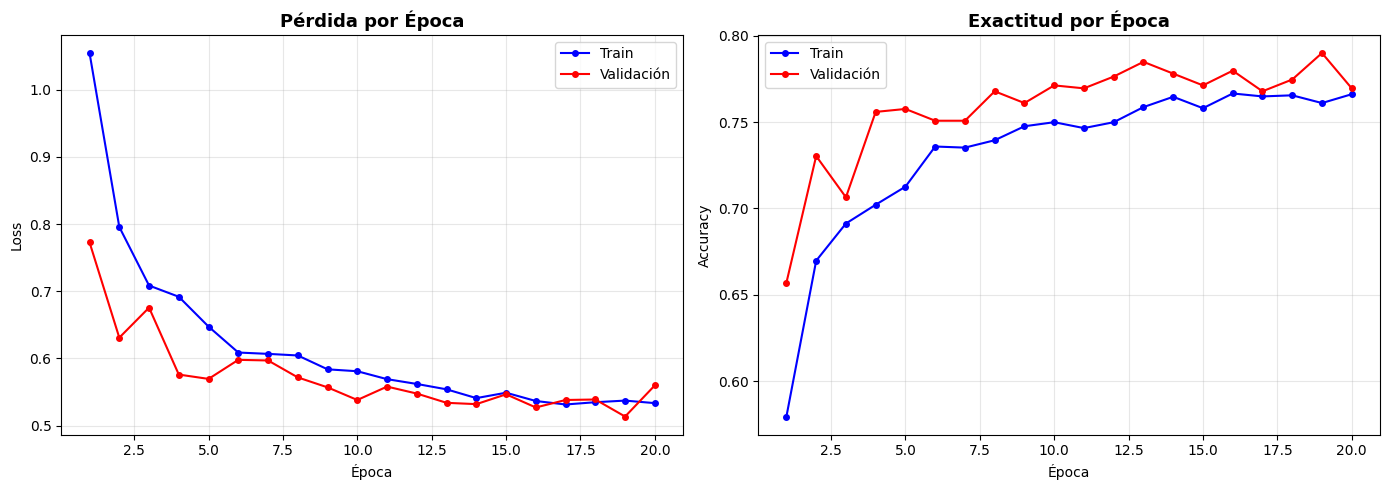

In [ ]:
epochs_range = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history.history['loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs_range, history.history['val_loss'], 'r-o', label='Validación', markersize=4)
axes[0].set_title('Pérdida por Época', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['accuracy'], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs_range, history.history['val_accuracy'], 'r-o', label='Validación', markersize=4)
axes[1].set_title('Exactitud por Época', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'curvas_entrenamiento.png'), dpi=150)
plt.show()


## 6.1 Fine-tuning  



Capas entrenables en base_model: 71 / 427
Pesos por clase (fine-tuning): {'normal': 1.233, 'bacteria': 0.702, 'virus': 1.7}
Epoch 1/20
147/147 [==============================] - 20s 100ms/step - loss: 0.5838 - accuracy: 0.7741 - precision: 0.7904 - recall: 0.7526 - val_loss: 0.5530 - val_accuracy: 0.7713 - val_precision: 0.7795 - val_recall: 0.7543 - lr: 1.0000e-05
Epoch 2/20
147/147 [==============================] - 15s 104ms/step - loss: 0.5802 - accuracy: 0.7720 - precision: 0.7872 - recall: 0.7534 - val_loss: 0.5444 - val_accuracy: 0.7833 - val_precision: 0.7947 - val_recall: 0.7662 - lr: 1.0000e-05
Epoch 3/20
147/147 [==============================] - 15s 103ms/step - loss: 0.5619 - accuracy: 0.7733 - precision: 0.7894 - recall: 0.7547 - val_loss: 0.5345 - val_accuracy: 0.7884 - val_precision: 0.7965 - val_recall: 0.7747 - lr: 1.0000e-05
Epoch 4/20
147/147 [==============================] - 12s 83ms/step - loss: 0.5675 - accuracy: 0.7718 - precision: 0.7846 - recall: 0.7549 - val

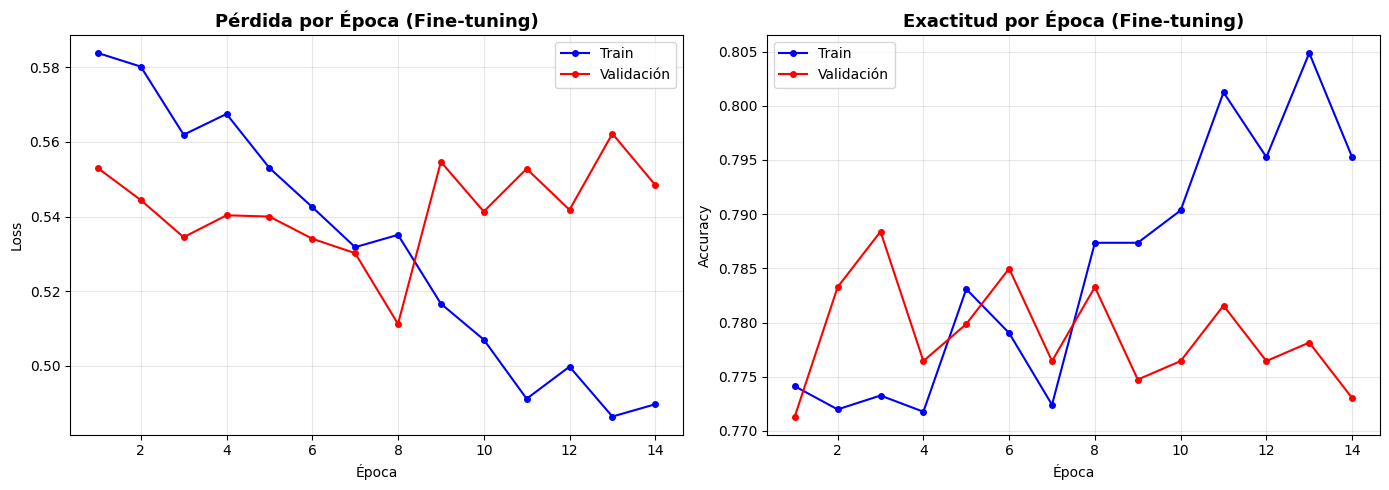

In [ ]:
FINE_TUNE = True
FINE_TUNE_AT = -100  

if FINE_TUNE:
    base_model.trainable = True
    n_layers = len(base_model.layers)

    for i, layer in enumerate(base_model.layers):
        if i < n_layers + FINE_TUNE_AT:
            layer.trainable = False
        elif isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    trainable_count = sum(l.trainable for l in base_model.layers)
    print(f"Capas entrenables en base_model: {trainable_count} / {n_layers}")


    class_weights_finetune = dict(class_weights)
    class_weights_finetune[CLASS_TO_IDX['virus']] *= 1.3
    print("Pesos por clase (fine-tuning):",
          {CLASSES[k]: round(v, 3) for k, v in class_weights_finetune.items()})

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')],
    )

    fine_tune_callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'best_densenet_finetuned.keras'), monitor='val_loss', save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ]

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        class_weight=class_weights_finetune,
        callbacks=fine_tune_callbacks,
    )

    epochs_range_ft = range(1, len(history_ft.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range_ft, history_ft.history['loss'], 'b-o', label='Train', markersize=4)
    axes[0].plot(epochs_range_ft, history_ft.history['val_loss'], 'r-o', label='Validación', markersize=4)
    axes[0].set_title('Pérdida por Época (Fine-tuning)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range_ft, history_ft.history['accuracy'], 'b-o', label='Train', markersize=4)
    axes[1].plot(epochs_range_ft, history_ft.history['val_accuracy'], 'r-o', label='Validación', markersize=4)
    axes[1].set_title('Exactitud por Época (Fine-tuning)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'curvas_finetuning.png'), dpi=150)
    plt.show()


## 6.2 Fine-tuning con Focal Loss 



In [ ]:
def categorical_focal_loss(gamma=2.0):
    def loss_fn(y_true, y_pred):
        epsilon = keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = tf.pow(1.0 - y_pred, gamma)
        loss_per_class = focal_weight * cross_entropy

        return tf.reduce_sum(loss_per_class, axis=-1)  

    return loss_fn


Continuando fine-tuning con Focal Loss (gamma=2.0)...
Epoch 1/10
147/147 [==============================] - 20s 96ms/step - loss: 0.2177 - accuracy: 0.7938 - precision: 0.8060 - recall: 0.7741 - val_loss: 0.2507 - val_accuracy: 0.7867 - val_precision: 0.7982 - val_recall: 0.7696 - lr: 5.0000e-06
Epoch 2/10
147/147 [==============================] - 14s 94ms/step - loss: 0.2055 - accuracy: 0.7788 - precision: 0.7961 - recall: 0.7534 - val_loss: 0.2392 - val_accuracy: 0.7799 - val_precision: 0.7954 - val_recall: 0.7696 - lr: 5.0000e-06
Epoch 3/10
147/147 [==============================] - 12s 78ms/step - loss: 0.2066 - accuracy: 0.7782 - precision: 0.7979 - recall: 0.7517 - val_loss: 0.2458 - val_accuracy: 0.7833 - val_precision: 0.7940 - val_recall: 0.7696 - lr: 5.0000e-06
Epoch 4/10
147/147 [==============================] - 12s 80ms/step - loss: 0.2016 - accuracy: 0.7889 - precision: 0.8037 - recall: 0.7615 - val_loss: 0.2848 - val_accuracy: 0.7628 - val_precision: 0.7726 - val_recall

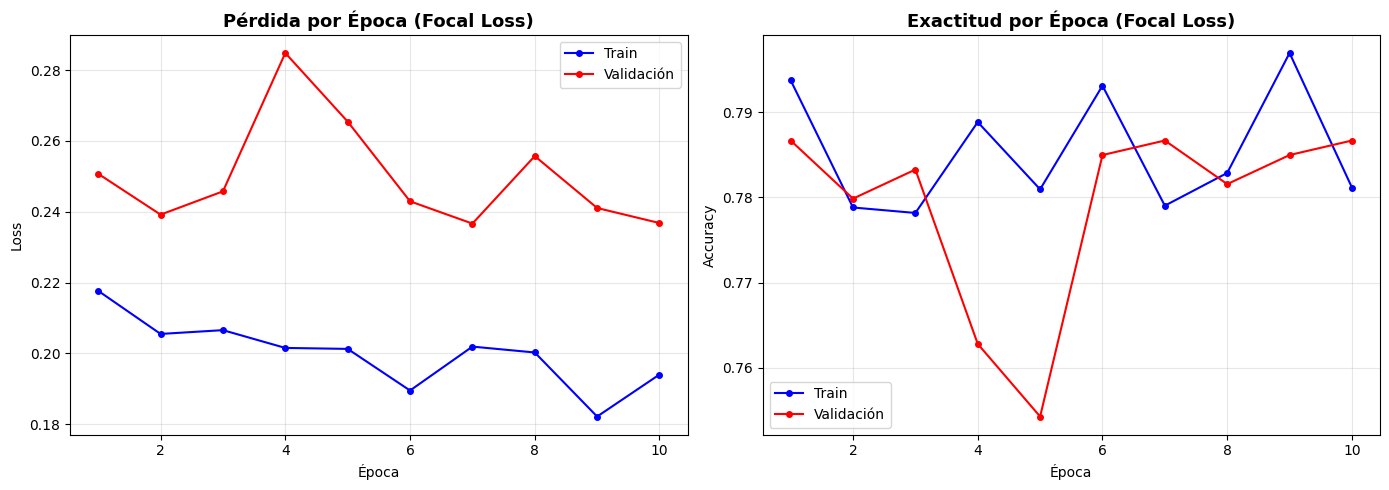


Modelo guardado en: ./outputs\modelo_densenet_focal.keras
Para evaluarlo en la sección 7, carga este archivo en vez de usar 'model' directamente,
o simplemente sigue -- 'model' en memoria YA tiene estos pesos (el mejor checkpoint).


In [ ]:
USE_FOCAL_LOSS = True  
FOCAL_GAMMA = 2.0      
FOCAL_EPOCHS = 10

if USE_FOCAL_LOSS:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-6), 
        loss=categorical_focal_loss(gamma=FOCAL_GAMMA),
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')],
    )

    focal_callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(
            os.path.join(OUTPUT_DIR, 'modelo_densenet_focal.keras'),
            monitor='val_loss', save_best_only=True,
        ),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ]

    print(f"Continuando fine-tuning con Focal Loss (gamma={FOCAL_GAMMA})...")
    history_focal = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FOCAL_EPOCHS,
        class_weight=class_weights,
        callbacks=focal_callbacks,
    )

    epochs_range_focal = range(1, len(history_focal.history['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range_focal, history_focal.history['loss'], 'b-o', label='Train', markersize=4)
    axes[0].plot(epochs_range_focal, history_focal.history['val_loss'], 'r-o', label='Validación', markersize=4)
    axes[0].set_title('Pérdida por Época (Focal Loss)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range_focal, history_focal.history['accuracy'], 'b-o', label='Train', markersize=4)
    axes[1].plot(epochs_range_focal, history_focal.history['val_accuracy'], 'r-o', label='Validación', markersize=4)
    axes[1].set_title('Exactitud por Época (Focal Loss)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'curvas_focal_loss.png'), dpi=150)
    plt.show()

    print("\nModelo guardado en:", os.path.join(OUTPUT_DIR, 'modelo_densenet_focal.keras'))
    print("Para evaluarlo en la sección 7, carga este archivo en vez de usar 'model' directamente,")
    print("o simplemente sigue -- 'model' en memoria YA tiene estos pesos (el mejor checkpoint).")


## 7. Confirmación de archivos guardados

Los checkpoints ya se fueron guardando automáticamente durante el
entrenamiento (vía `ModelCheckpoint`, cada vez que mejoraba `val_loss`).
Esta celda solo confirma qué quedó en disco, para saber qué archivo usar
en `03_Validacion.ipynb`.


In [ ]:
print("Archivos de modelo disponibles en", OUTPUT_DIR, ":\n")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.keras'):
        path = os.path.join(OUTPUT_DIR, f)
        size_mb = os.path.getsize(path) / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")

print("\nUsa el más reciente/completo entrenado (normalmente el de Focal Loss")
print("si USE_FOCAL_LOSS=True, si no el de fine-tuning) en el notebook 3/3.")


Archivos de modelo disponibles en ./outputs :

  best_densenet_finetuned.keras  (45.9 MB)
  best_densenet_model.keras  (30.5 MB)
  modelo_densenet_focal.keras  (45.9 MB)

Usa el más reciente/completo entrenado (normalmente el de Focal Loss
si USE_FOCAL_LOSS=True, si no el de fine-tuning) en el notebook 3/3.


## Siguiente paso

Abre **`03_Validacion.ipynb`**, ajusta `OUTPUT_DIR` igual que aquí, y
define `MODEL_PATH` apuntando al archivo `.keras` que quieras evaluar (la
celda de confirmación de arriba te muestra los disponibles).
